In [24]:
import pandas as pd
import numpy as np
from pathlib import Path

## Phase 1. Generate 100K unknown data
---
Store `unknown_car.data.csv` in $data$ folder

In [25]:
def generate_unknown_data(n_rows: int = 100_000, random_state: int = 42) -> None:
    """
    Introduce 'unknown' values randomly in the DataFrame.

    Parameters:
    - n_rows: Number of rows to generate.
    - random_state: Seed for reproducibility.

    Returns:
    - None,
    creates a csv file 'unknown_car_data.csv' in /data folder
    """
    # Set random seed for reproducibility
    np.random.seed(random_state)

    # Define categories based on UCI Car Dataset
    data_config = {
        "price": ["vhigh", "high", "med", "low"],
        "maintenance": ["vhigh", "high", "med", "low"],
        "doors": ["2", "3", "4", "5more"],
        "seats": ["2", "4", "more"],
        "storage": ["small", "med", "big"],
        "safety": ["low", "med", "high"],
        "shouldBuy": ["unacc", "acc", "vgood", "good"],
    }

    # Define imbalanced weights for 'shouldBuy' (Target)
    # Original UCI distribution is roughly: unacc (~70%), acc (~22%), good (~4%), vgood (~4%)
    target_classes = ["unacc", "acc", "good", "vgood"]
    target_weights = [0.70, 0.22, 0.04, 0.04]

    # Create base synthetic data with random features
    data = {col: np.random.choice(vals, size=n_rows) for col, vals in data_config.items()}

    # Generate imbalanced target labels
    data["shouldBuy"] = np.random.choice(target_classes, size=n_rows, p=target_weights)

    df_imbalanced = pd.DataFrame(data)

    # Function to inject various types of missingness (The "Chaos" from before)
    def inject_chaos(df, p=0.05):
        n = len(df)
        for col in df.columns:
            indices = np.random.choice(n, size=int(n * p), replace=False)
            idx_splits = np.array_split(indices, 5)

            df.loc[idx_splits[0], col] = np.nan
            df.loc[idx_splits[1], col] = None
            df.loc[idx_splits[2], col] = ""
            df.loc[idx_splits[3], col] = "null"
            df.loc[idx_splits[4], col] = "NaN"
        return df

    # Inject 5% chaos to maintain the real-world difficulty
    df_imbalanced_dirty = inject_chaos(df_imbalanced, p=0.05)

    # Setup path and save
    results_dir = Path.cwd().parent / "data"
    results_dir.mkdir(parents=True, exist_ok=True)
    file_path = results_dir / "unknown_car_data.csv"

    df_imbalanced_dirty.to_csv(file_path, index=False)

    # Verification
    print(f"Generated {n_rows} rows of imbalanced unknown data.")
    print(f"File saved to: {file_path}")
    print("\nTarget Class Distribution (Should match UCI proportions):")
    print(df_imbalanced_dirty["shouldBuy"].value_counts(normalize=True))

    return df_imbalanced_dirty

# Phase 2: Test the models
--- 
We created models in classification.ipynb; we must test them here

In [26]:
# Load Data
df_unknown = pd.read_csv(Path.cwd().parent / "data" / "unknown_car_data.csv")
display(df_unknown.sample(10))

,price,maintenance,doors,seats,storage,safety,shouldBuy
52799,med,high,3,more,NaN,high,unacc
34950,low,low,3,NaN,med,high,unacc
48844,NaN,med,2,more,big,high,unacc
19802,med,vhigh,2,2,med,high,unacc
38331,vhigh,high,5more,4,med,med,NaN
5403,low,vhigh,5more,4,med,low,unacc
44149,vhigh,low,4,more,big,low,unacc
33876,vhigh,high,2,more,small,med,unacc
96598,vhigh,med,2,more,small,low,unacc
44108,low,low,4,4,big,high,acc


In [27]:
df_unknown.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   price        95000 non-null  object
 1   maintenance  95000 non-null  object
 2   doors        95000 non-null  object
 3   seats        95000 non-null  object
 4   storage      95000 non-null  object
 5   safety       95000 non-null  object
 6   shouldBuy    95000 non-null  object
dtypes: object(7)
memory usage: 5.3+ MB


## Test on pre-trained models

In [28]:
from car_transformers import CarDataCleaner, CarDataImputer, CarDataEncoder

In [29]:
import os
from pathlib import Path

# Check current location
print(f"Current Working Directory: {Path.cwd()}")

# Check results directory
results_dir = Path.cwd().parent / "results"
print(f"Looking for results at: {results_dir.resolve()}")

if results_dir.exists():
    files = list(results_dir.glob("*"))
    print(f"\nFiles found in /results ({len(files)}):")
    for f in files:
        print(f" - {f.name}")
else:
    print("\n❌ The /results directory does not exist at that path!")

Current Working Directory: /home/bhavik/Dropbox/edu/smu/winter/data_mining/a2_classification/mcda5580-data-mining-a2-classification/code
Looking for results at: /home/bhavik/Dropbox/edu/smu/winter/data_mining/a2_classification/mcda5580-data-mining-a2-classification/results

Files found in /results (53):
 - diagnostic_ANN.png
 - diagnostic_KNN_K3.png
 - diagnostic_NaiveBayes.png
 - diagnostic_RandomForest.png
 - diagnostic_SVM_Linear.png
 - diagnostic_SVM_RBF.png
 - diagnostic_XGBoost.png
 - model_performance_distribution.png
 - model_suite.pkl
 - knn_tuning_elbow_plot.png
 - model_efficiency_scatter.png
 - master_model_comparison.csv
 - boxplot_model_vs_f1_test.png
 - boxplot_f1_stability.png
 - boxplot_training_cv_f1.png
 - pipeline_model_efficiency_scatter.png
 - pipeline_model_performance_distribution.png
 - final_pipeline_test_metrics.csv
 - final_test_metrics_with_time.csv
 - pipeline_comprehensive_model_comparison.csv
 - final_metric_comparison_facets.png
 - final_metric_comparis

In [32]:
import joblib
import pandas as pd
from pathlib import Path
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score

# 1. IMPORTANT: Import your blueprints from the local file
from car_transformers import CarDataCleaner, CarDataImputer, CarDataEncoder

# 2. Setup verified path
results_dir = Path("/home/bhavik/Dropbox/edu/smu/winter/data_mining/a2_classification/mcda5580-data-mining-a2-classification/results")

# 3. Load items
le = joblib.load(results_dir / "label_encoder.joblib")
# Filter specifically for the joblib files starting with 'pipeline_'
pipeline_files = list(results_dir.glob("pipeline_*.joblib"))
pipeline_files = [f for f in pipeline_files if "label_encoder" not in f.name]

# 4. Prepare Data (Assumes df_unknown is in memory)
df_eval = df_unknown.dropna(subset=['shouldBuy']).copy()
X_unknown = df_eval[['price', 'maintenance', 'doors', 'seats', 'storage', 'safety']]
y_true_encoded = le.transform(df_eval['shouldBuy'])

# 5. The Dictionary Loop
unknown_performance = dict()

print(f"🚀 Found {len(pipeline_files)} models. Starting 100,000 row evaluation...")

for model_file in pipeline_files:
    # Remove 'pipeline_' prefix and '.joblib' suffix for the dictionary key
    model_name = model_file.stem.replace("pipeline_", "")
    
    try:
        # Load the pipeline - now it knows the CarDataCleaner blueprint
        pipeline = joblib.load(model_file)
        
        # Massive Batch Inference on i9-13900K
        y_pred = pipeline.predict(X_unknown)
        
        # Calculate all required metrics
        unknown_performance[model_name] = {
            "unknown_f1": f1_score(y_true_encoded, y_pred, average="macro"),
            "unknown_accuracy": accuracy_score(y_true_encoded, y_pred),
            "unknown_precision": precision_score(y_true_encoded, y_pred, average="macro", zero_division=0),
            "unknown_recall": recall_score(y_true_encoded, y_pred, average="macro", zero_division=0)
        }
        print(f"   ✅ {model_name} processing complete.")
        
    except Exception as e:
        print(f"   ❌ Error loading {model_name}: {e}")

# 6. Final Comprehensive Table for LaTeX
if unknown_performance:
    df_unknown_full_metrics = pd.DataFrame.from_dict(unknown_performance, orient='index')
    df_unknown_full_metrics.index.name = 'model'
    df_unknown_full_metrics = df_unknown_full_metrics.sort_values(by="unknown_f1", ascending=False)
    
    display(df_unknown_full_metrics.style.format("{:.4f}"))
    
    # Save for the final report
    df_unknown_full_metrics.to_csv(results_dir / "stress_test_100k_final_full_metrics.csv")
else:
    print("‼️ Evaluation failed. Check data format or class imports.")


🚀 Found 7 models. Starting 100,000 row evaluation...
   ✅ NaiveBayes processing complete.
   ✅ KNN_K3 processing complete.
   ✅ SVM_Linear processing complete.
   ✅ SVM_RBF processing complete.
   ✅ RandomForest processing complete.
   ✅ XGBoost processing complete.
   ✅ ANN processing complete.


,unknown_f1,unknown_accuracy,unknown_precision,unknown_recall
model,,,,
XGBoost,0.2504,0.5305,0.2505,0.2505
ANN,0.2501,0.5326,0.2502,0.2502
RandomForest,0.2501,0.5276,0.2503,0.2503
KNN_K3,0.2496,0.5279,0.2498,0.2498
SVM_RBF,0.2493,0.5078,0.2504,0.2505
SVM_Linear,0.2455,0.4691,0.2502,0.2507
NaiveBayes,0.2226,0.5012,0.2490,0.2495


## Plot results for unknown data

🚀 Generating diagnostic cards for 7 models on 100k records...


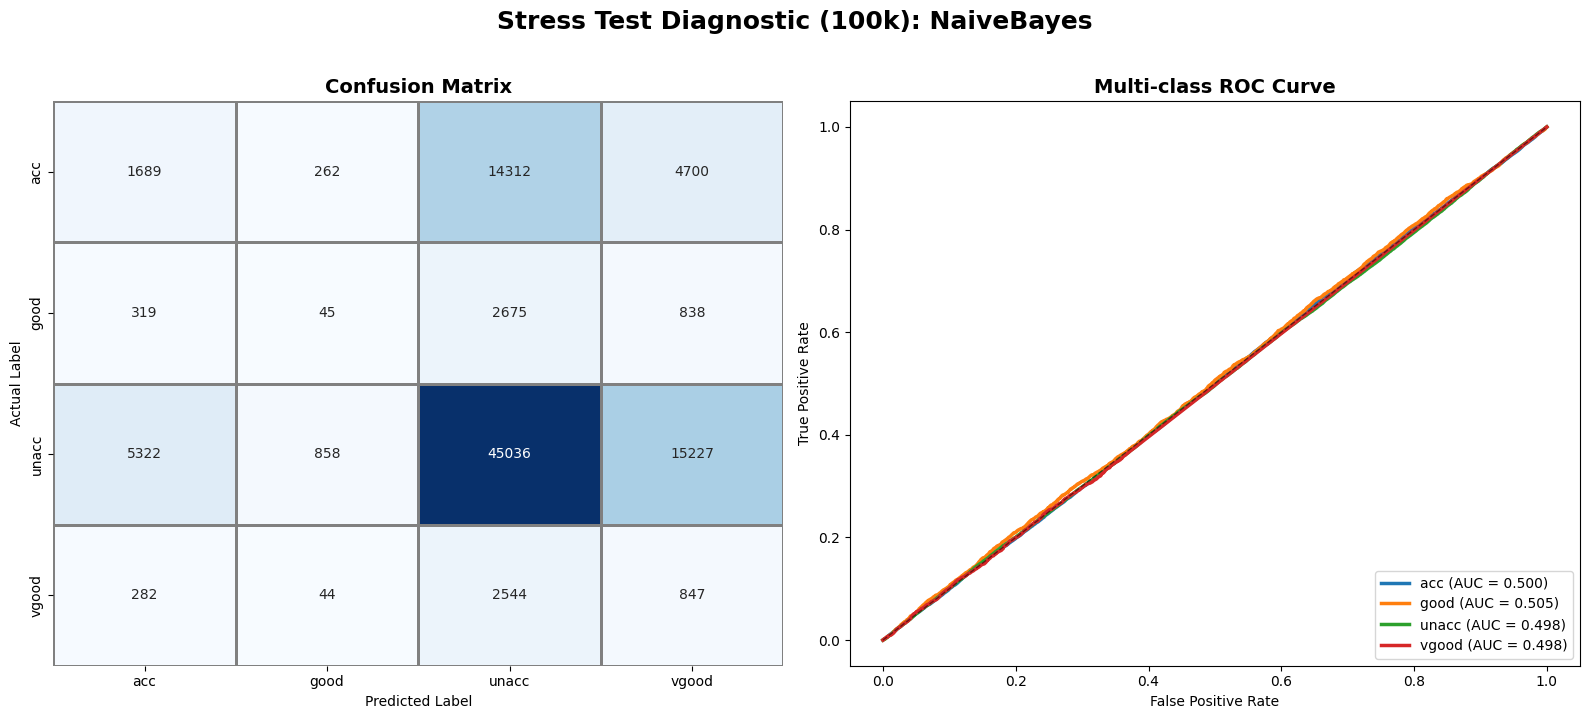

   ✅ Exported: stress_diagnostic_NaiveBayes.png


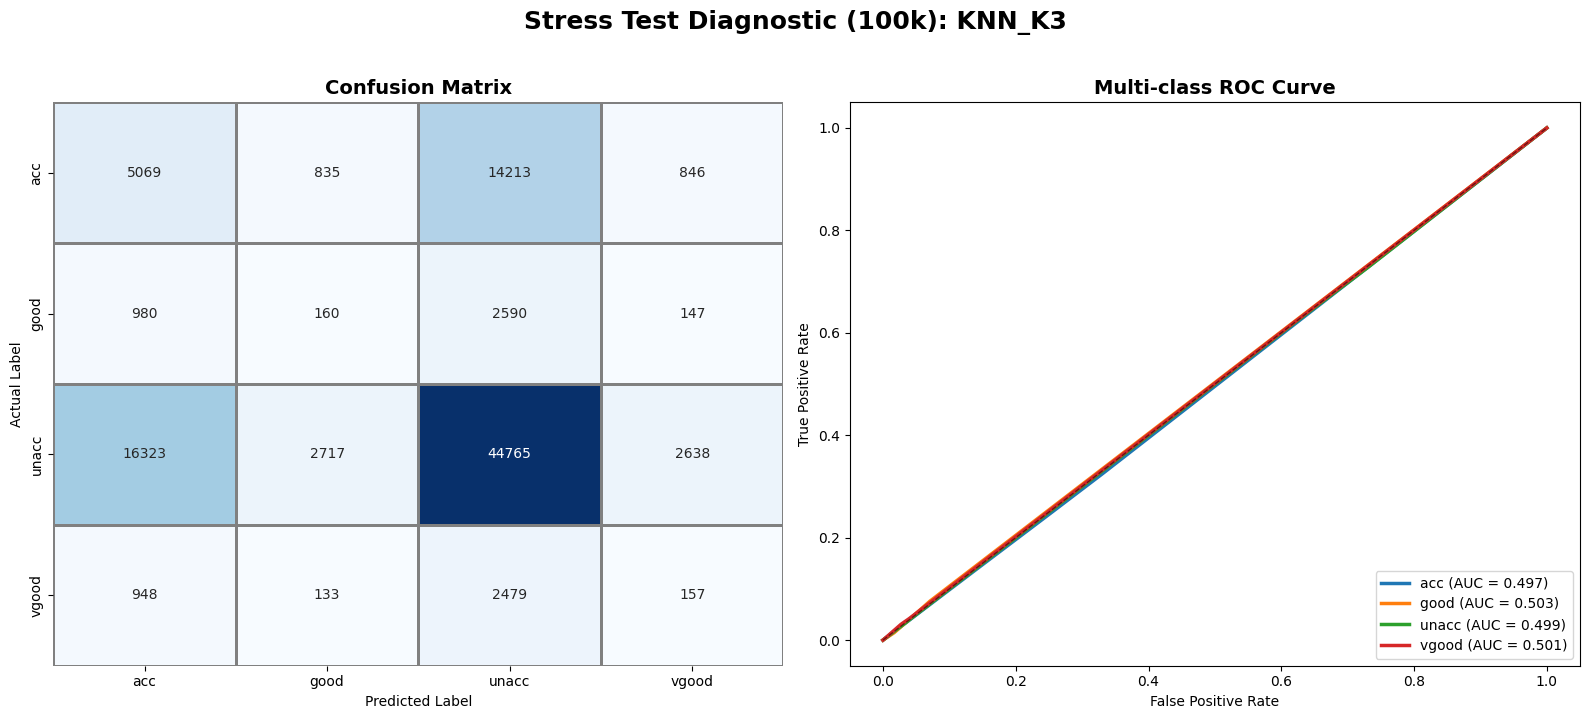

   ✅ Exported: stress_diagnostic_KNN_K3.png


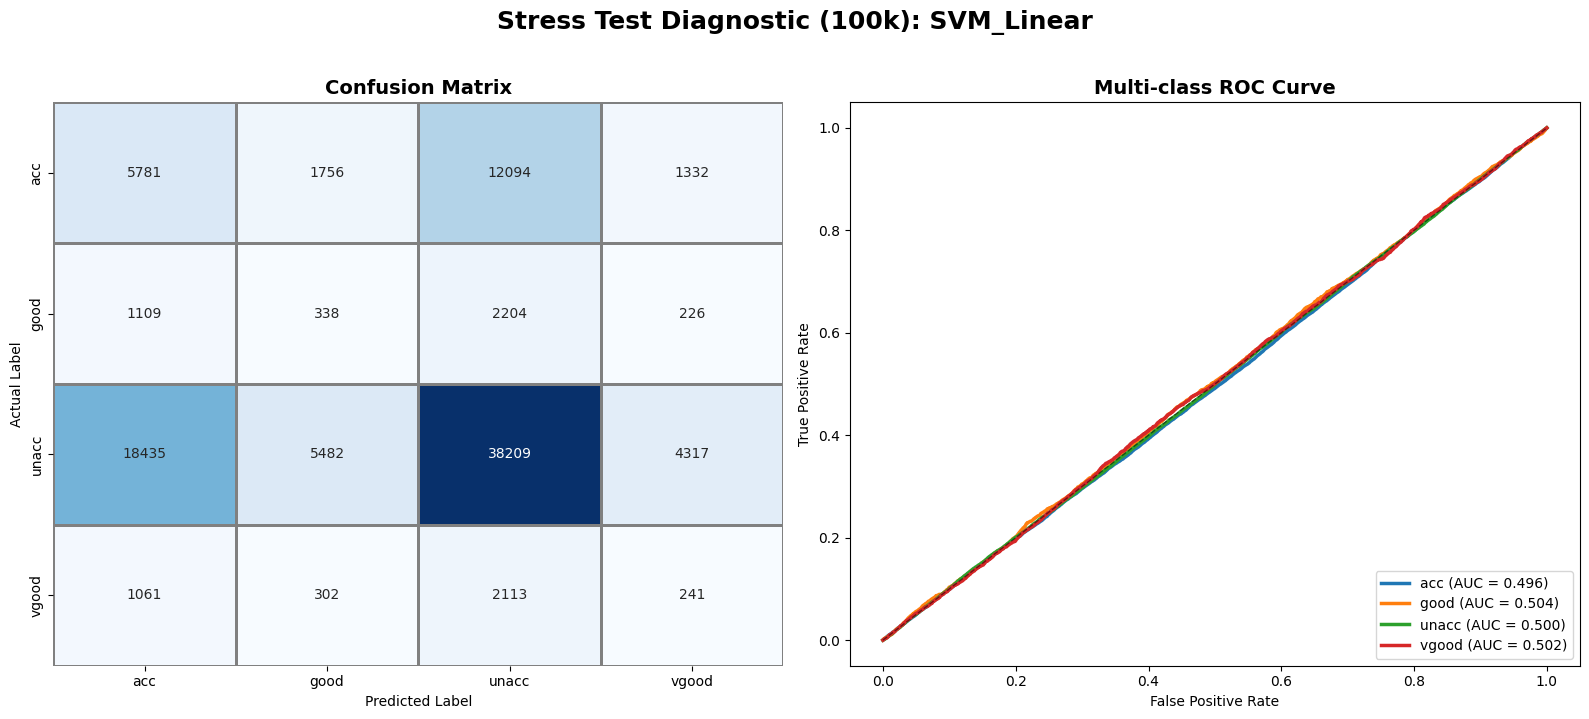

   ✅ Exported: stress_diagnostic_SVM_Linear.png


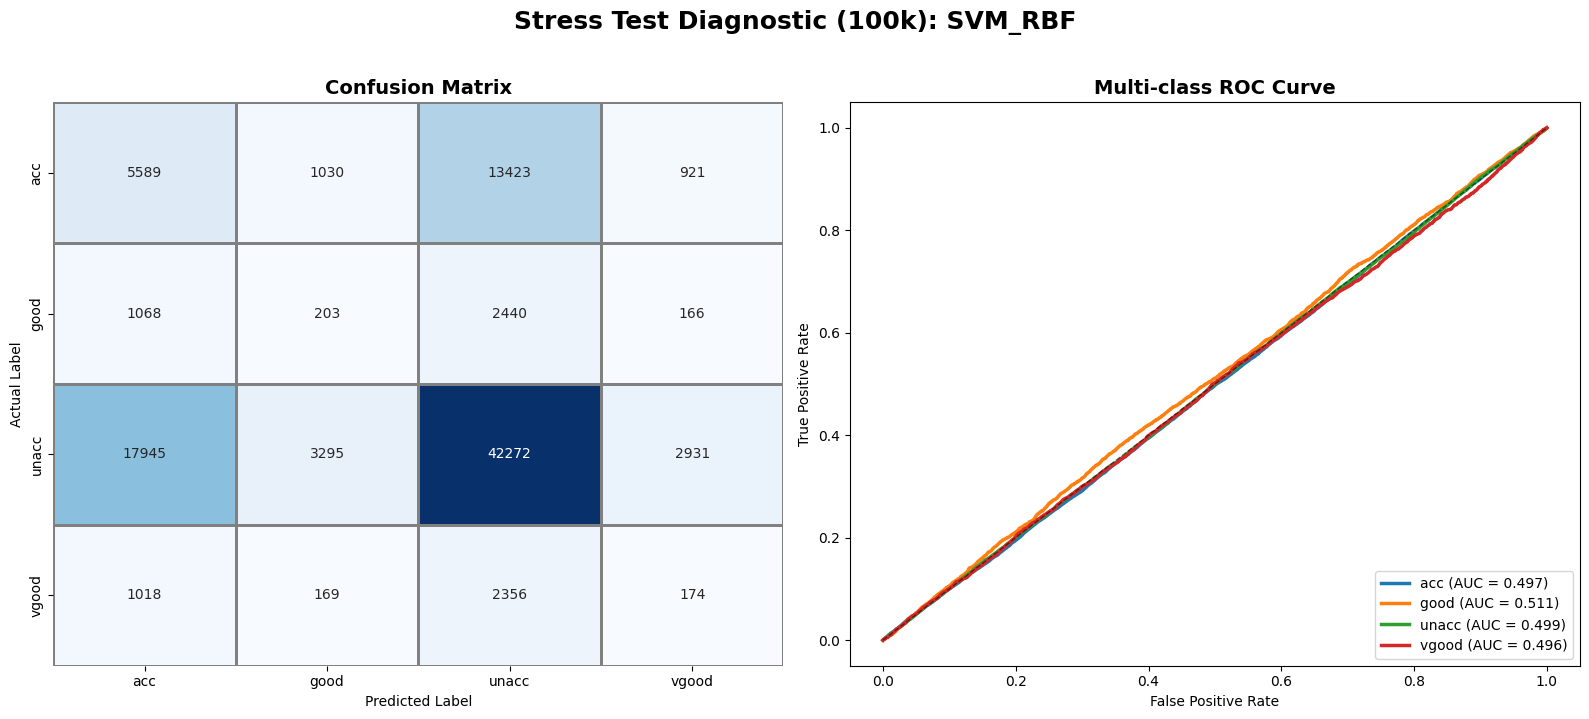

   ✅ Exported: stress_diagnostic_SVM_RBF.png


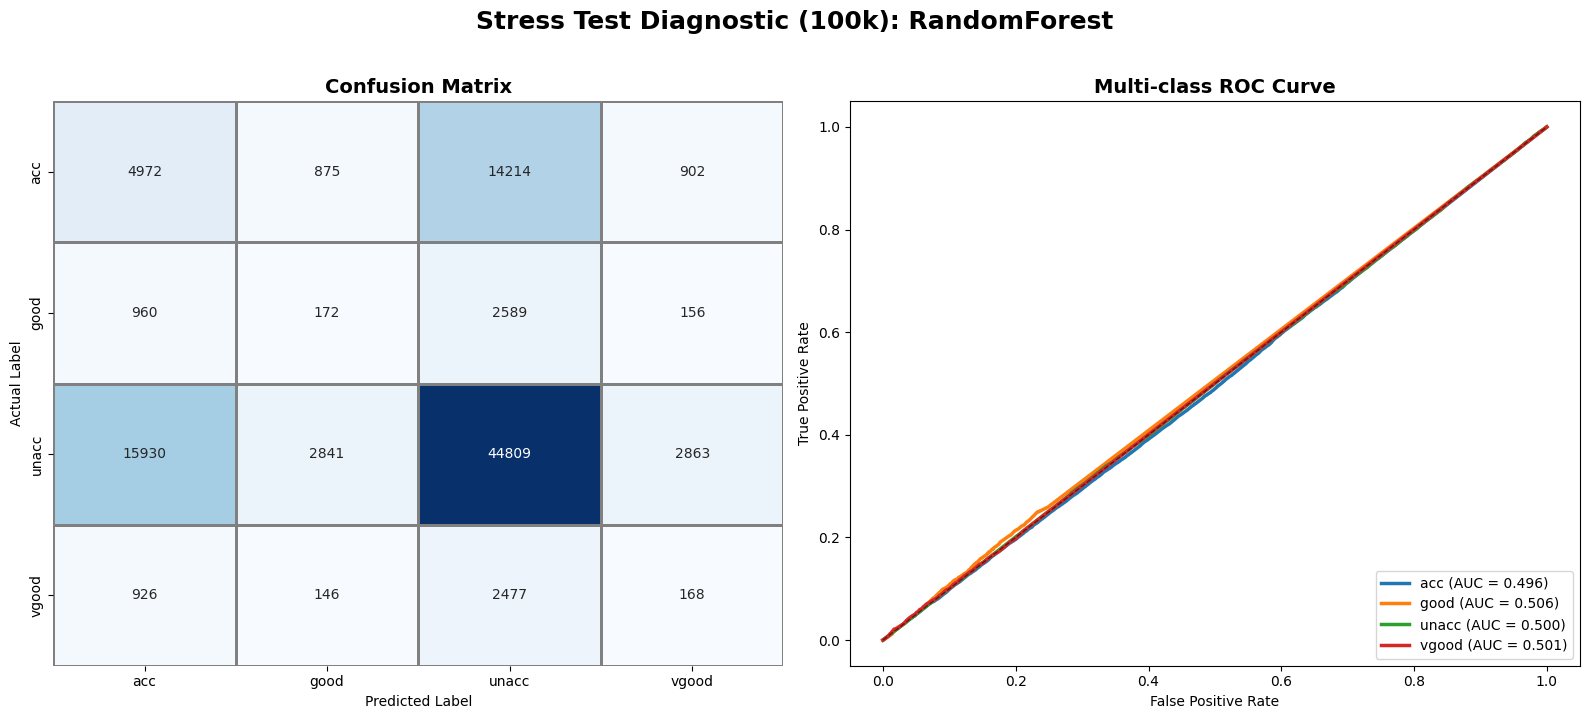

   ✅ Exported: stress_diagnostic_RandomForest.png


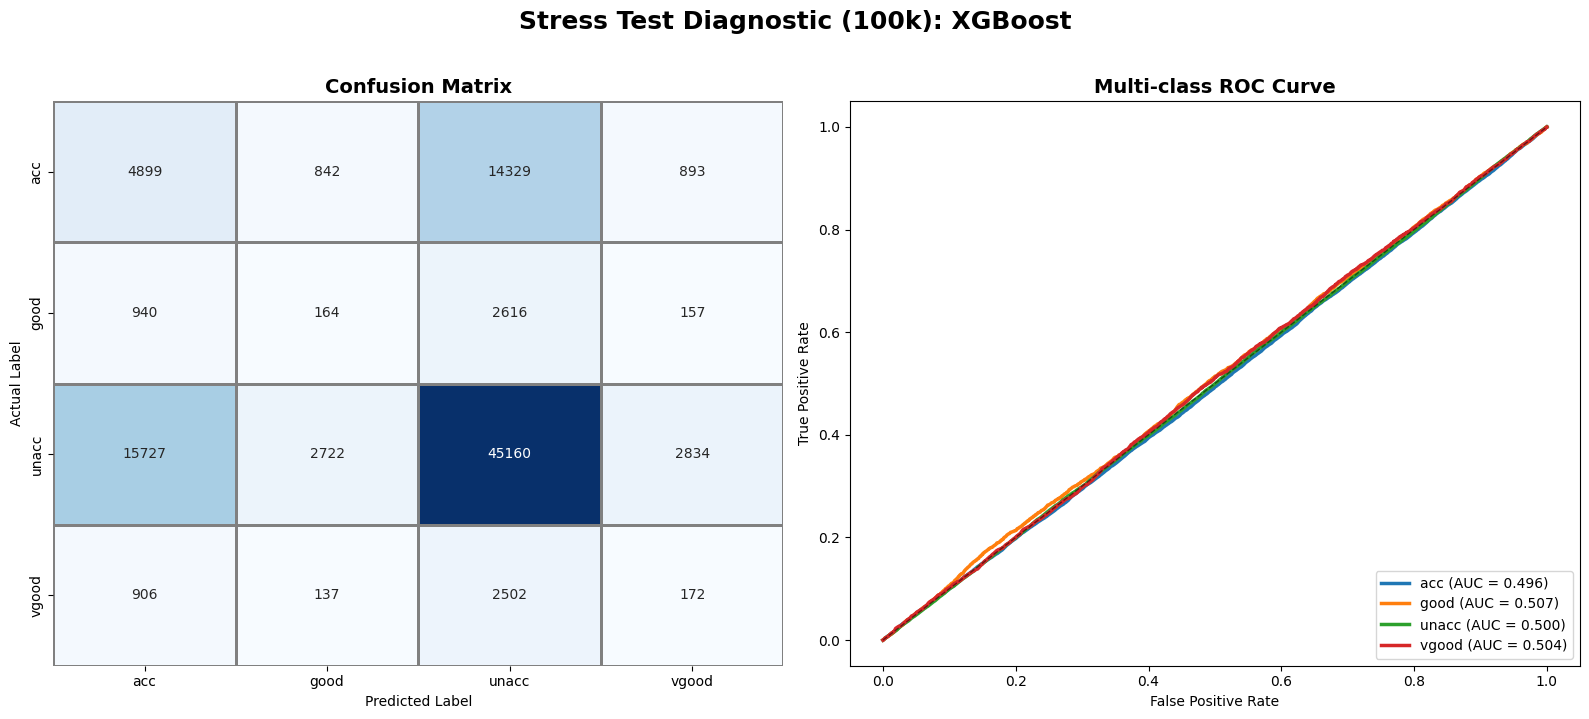

   ✅ Exported: stress_diagnostic_XGBoost.png


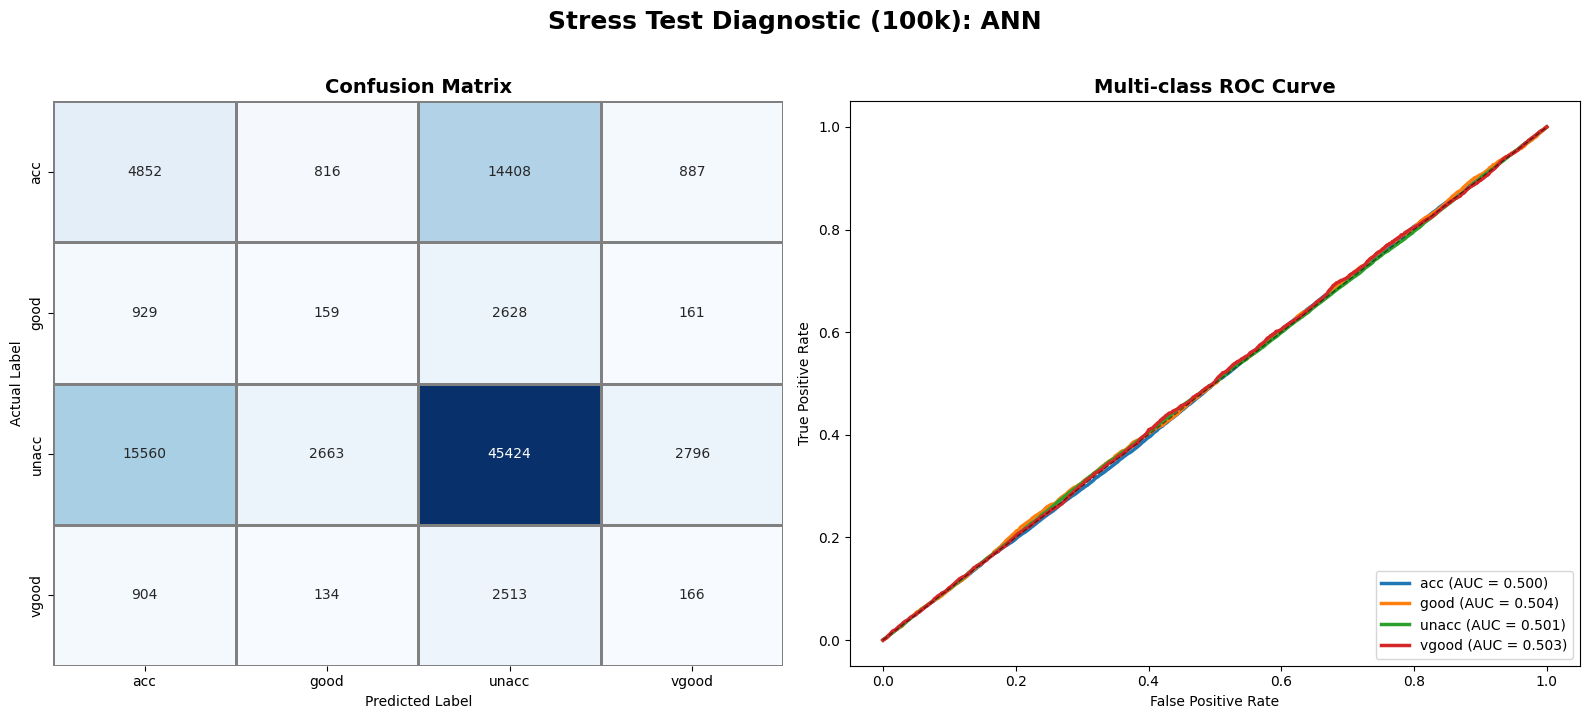

   ✅ Exported: stress_diagnostic_ANN.png

All stress-test diagnostic cards have been generated.


In [31]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# 1. Setup paths
results_dir = Path.cwd().parent / "results"
results_dir.mkdir(parents=True, exist_ok=True)

# 2. Load LabelEncoder and Prepare Data
le = joblib.load(results_dir / "label_encoder.joblib")
class_names = le.classes_

# Prepare the 100k dataset (assuming df_unknown is in memory)
df_eval = df_unknown.dropna(subset=['shouldBuy']).copy()
X_unknown = df_eval[['price', 'maintenance', 'doors', 'seats', 'storage', 'safety']]
y_true_encoded = le.transform(df_eval['shouldBuy'])
y_true_bin = label_binarize(y_true_encoded, classes=[0, 1, 2, 3])

# 3. Filter model pipelines
all_joblibs = list(results_dir.glob("*.joblib"))
pipeline_files = [f for f in all_joblibs if "label_encoder" not in f.name]

print(f"🚀 Generating diagnostic cards for {len(pipeline_files)} models on 100k records...")

for model_file in pipeline_files:
    model_name = model_file.stem.replace("pipeline_", "")
    
    try:
        # Load the pipeline
        pipeline = joblib.load(model_file)
        
        # Get Predictions and Probabilities
        y_pred = pipeline.predict(X_unknown)
        y_score = pipeline.predict_proba(X_unknown)
        
        # --- Create Side-by-Side Plot ---
        fig, (ax_cm, ax_roc) = plt.subplots(1, 2, figsize=(16, 7))
        plt.subplots_adjust(wspace=0.3)

        # A. Confusion Matrix (Left)
        cm = confusion_matrix(y_true_encoded, y_pred)
        sns.heatmap(
            cm, annot=True, fmt="d", cmap="Blues", ax=ax_cm,
            xticklabels=class_names, yticklabels=class_names,
            cbar=False, linewidths=1, linecolor="gray"
        )
        ax_cm.set_title(f"Confusion Matrix", fontsize=14, fontweight="bold")
        ax_cm.set_ylabel("Actual Label")
        ax_cm.set_xlabel("Predicted Label")

        # B. ROC Curve (Right)
        colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
        for i, color in zip(range(len(class_names)), colors):
            fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
            roc_auc = auc(fpr, tpr)
            ax_roc.plot(fpr, tpr, color=color, lw=2.5, label=f"{class_names[i]} (AUC = {roc_auc:.3f})")

        ax_roc.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
        ax_roc.set_title(f"Multi-class ROC Curve", fontsize=14, fontweight="bold")
        ax_roc.set_xlabel("False Positive Rate")
        ax_roc.set_ylabel("True Positive Rate")
        ax_roc.legend(loc="lower right", fontsize=10)

        # Final Formatting
        fig.suptitle(f"Stress Test Diagnostic (100k): {model_name}", fontsize=18, fontweight="bold", y=1.02)
        plt.tight_layout()

        # Save the result
        clean_name = model_name.replace(" ", "_").replace("(", "").replace(")", "").replace("=", "")
        save_path = results_dir / f"stress_diagnostic_{clean_name}.png"
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close(fig)
        
        print(f"   ✅ Exported: {save_path.name}")

    except Exception as e:
        print(f"   ❌ Error with {model_name}: {e}")

print("\nAll stress-test diagnostic cards have been generated.")